In [55]:
# Import Library yang dibutuhkan
import pickle # menggunakan pickle untuk load data
import sys # menggunakan sys untuk mengatasi error pada versi pandas terbaru
import pandas as pd
import numpy as np
df= pd.read_pickle('../data/wm811k_v2.pkl')
print("Library dan data yang dibutuhkan sudah diimport")

Library dan data yang dibutuhkan sudah diimport


In [56]:
df.isnull().sum()

waferMap                0
dieSize                 0
lotName                 0
waferIndex              0
trianTestLabel          0
failureType             0
failureType_clean       0
trainTestLabel_clean    0
stratify_key            0
dtype: int64

In [57]:
# apakah ada duplikasi baris pada data?
df.duplicated(subset=['lotName', 'waferIndex', 'dieSize']).sum()

np.int64(0)

In [58]:
print(f"berikut column pada dataset: {df.columns}")
print(f"tipe data pada dataset: {df.dtypes}")

berikut column pada dataset: Index(['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel',
       'failureType', 'failureType_clean', 'trainTestLabel_clean',
       'stratify_key'],
      dtype='str')
tipe data pada dataset: waferMap                 object
dieSize                 float64
lotName                  object
waferIndex              float64
trianTestLabel           object
failureType              object
failureType_clean           str
trainTestLabel_clean        str
stratify_key                str
dtype: object


In [59]:
pd.crosstab(df['trainTestLabel_clean'], df['failureType_clean'])

failureType_clean,Center,Donut,Edge-Loc,Edge-Ring,Loc,Near-full,Random,Scratch,none
trainTestLabel_clean,,,,,,,,,
Test,832,146,2772,1126,1973,95,257,693,110701
Training,3462,409,2417,8554,1620,54,609,500,36730
none,0,0,0,0,0,0,0,0,638507


In [60]:
# mari kita liat berapa banyak memori yang digunakan oleh dataset sebelum optimasi
memori_sebelum = df.memory_usage(deep=True).sum() / 1e6
print(f"Memori sebelum optimasi: {memori_sebelum:.2f} MB")

Memori sebelum optimasi: 553.19 MB


In [61]:
# mari kita optimasi tipe data pada kolom kategorikal agar lebih hemat memori
kolom_kategorikal = ['stratify_key', 'failureType_clean', 'trainTestLabel_clean', 'lotName']
# kita buat fungsi untuk mengubah tipe data kolom kategorikal menjadi 'category'
def optimize_categorical_columns(df, columns):
    for col in columns:
        df[col] = df[col].astype('category')
    return df

df = optimize_categorical_columns(df, kolom_kategorikal)

# kita akan downcast kolom numerik agar lebih hemat memori
# kita cek apakah kolom dieSize dan waferIndex sudah integer
print((df['dieSize'] % 1 != 0).sum())      # harus 0
print((df['waferIndex'] % 1 != 0).sum())   # harus 0

# mari kita downcast kolom dieSize dan waferIndex menjadi integer
df['dieSize'] = pd.to_numeric(df['dieSize'], downcast='integer')
df['waferIndex'] = pd.to_numeric(df['waferIndex'], downcast='integer')

# kita cek apakah sudah teroptimasi dengan baik
memori_sesudah = df.memory_usage(deep=True).sum() / 1e6
print(f"Memori sesudah optimasi: {memori_sesudah:.2f} MB")
print(f"Penghematan: {(1 - memori_sesudah/memori_sebelum)*100:.1f}%")

0
0
Memori sesudah optimasi: 344.55 MB
Penghematan: 37.7%


In [62]:
# mari kita ubah label kolom menjadi lebih mudah dibaca
kode_singkat = {
    'unlabeled': 'UNL',
    'reviewed_no_defect': 'RND',
    'Center': 'C',
    'Donut': 'D',
    'Edge-Loc': 'EL',
    'Edge-Ring': 'ER',
    'Loc': 'L',
    'Near-full': 'NF',
    'Random': 'R',
    'Scratch': 'S'
}
# kita akan membuat kolom baru 'stratify_key_short' yang berisi kode singkat dari 'stratify_key'
# dengan apply() dan lambda function akan mengubah setiap value pada kolom 'stratify_key' menjadi kode singkat sesuai dengan dictionary kode_singkat
df['stratify_key_short'] = df['stratify_key'].apply(lambda x: kode_singkat[x])

# mari kita cek apakah ada nilai null pada kolom 'stratify_key_short'
print(df['stratify_key_short'].isnull().sum())  # harus 0

0


In [63]:
# mari kita liat sebaran data ukuran dieSize pada dataset
print(df['dieSize'].describe())
print(df['dieSize'].quantile([0.25, 0.5, 0.75]))

count    811457.000000
mean       1840.998585
std        2254.987374
min           3.000000
25%         710.000000
50%         953.000000
75%        1902.000000
max       48099.000000
Name: dieSize, dtype: float64
0.25     710.0
0.50     953.0
0.75    1902.0
Name: dieSize, dtype: float64


In [64]:
# berdasarkan quantile, kita akan membuat binning pada kolom dieSize menjadi 3 kategori: kecil, sedang, besar
bins = [0, 710, 1902, np.inf]
labels = ['kecil', 'sedang', 'besar']
df['dieSize_binned'] = pd.cut(df['dieSize'], bins=bins, labels=labels)

print(df['dieSize_binned'].value_counts())

dieSize_binned
sedang    387761
kecil     220840
besar     202856
Name: count, dtype: int64


In [65]:
# kita cek anomali pada dieSize, apakah ada nilai yang tidak masuk dalam binning
print(df[df['dieSize'] < 10][['lotName', 'waferIndex', 'dieSize', 'failureType_clean']])

         lotName  waferIndex  dieSize failureType_clean
145730  lot44867          20        3              none


In [66]:
# mari kita cek status review 145730
print(df.loc[145730, 'trainTestLabel_clean'])

Training


Shape: (15, 3)
[[0 1 1]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [1 0 0]]


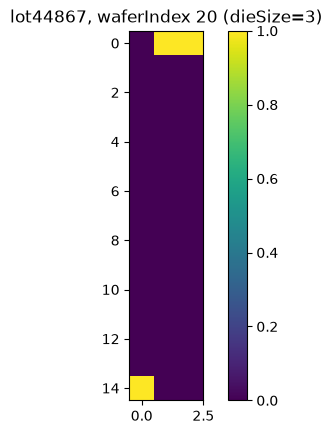

In [67]:
wafer_aneh = df.loc[145730, 'waferMap']
print(f"Shape: {wafer_aneh.shape}")
print(wafer_aneh)

import matplotlib.pyplot as plt
plt.imshow(wafer_aneh)
plt.title("lot44867, waferIndex 20 (dieSize=3)")
plt.colorbar()
plt.show()

In [68]:
# apakah ada anomali lain pada dieSize yang lebih kecil dari 100?
print(df[df['dieSize'] < 100]['dieSize'].value_counts().sort_index())

dieSize
3      1
12     1
21     2
31     1
34     3
50     1
54     1
60     1
79     1
82    25
91    25
96     1
97     4
Name: count, dtype: int64


In [69]:
for val in [82, 91]:
    print(f"\n--- dieSize == {val} ---")
    print(df[df['dieSize'] == val]['waferMap'].apply(lambda x: x.shape).value_counts())


--- dieSize == 82 ---
waferMap
(10, 11)    25
Name: count, dtype: int64

--- dieSize == 91 ---
waferMap
(10, 12)    25
Name: count, dtype: int64


In [70]:
print(df[df['dieSize'] < 100]['failureType_clean'].value_counts())

failureType_clean
none         67
Center        0
Donut         0
Edge-Loc      0
Edge-Ring     0
Loc           0
Near-full     0
Random        0
Scratch       0
Name: count, dtype: int64


In [71]:
# kita cek apakah ada anomali pada dieSize 96 dan 97, apakah ada waferMap yang tidak sesuai dengan ukuran dieSize
for val in [96, 97]:
    print(f"\n--- dieSize == {val} ---")
    print(df[df['dieSize'] == val]['waferMap'].apply(lambda x: x.shape).value_counts())


--- dieSize == 96 ---
waferMap
(34, 48)    1
Name: count, dtype: int64

--- dieSize == 97 ---
waferMap
(11, 11)    4
Name: count, dtype: int64


In [72]:
# sepertinya ukuran 96 terlihat anomali, mari kita cek lebih detail lagi keseluruhan data
df['total_cells'] = df['waferMap'].apply(lambda x: x.shape[0] * x.shape[1])
df['fill_ratio'] = df['dieSize'] / df['total_cells']

print(df['fill_ratio'].describe())
print(df['fill_ratio'].quantile([0.01, 0.05, 0.10, 0.25, 0.5]))

count    811457.000000
mean          0.774215
std           0.030675
min           0.007353
25%           0.765086
50%           0.776860
75%           0.787104
max           0.844407
Name: fill_ratio, dtype: float64
0.01    0.745358
0.05    0.760784
0.10    0.762747
0.25    0.765086
0.50    0.776860
Name: fill_ratio, dtype: float64


In [73]:
# kita cek tail population pada fill_ratio
anomali_fill = df[df['fill_ratio'] < 0.3]
print(f"Jumlah baris fill_ratio < 30%: {len(anomali_fill)}")
print(anomali_fill['failureType_clean'].value_counts())
print(anomali_fill['dieSize'].describe())

Jumlah baris fill_ratio < 30%: 2031
failureType_clean
none         2031
Center          0
Donut           0
Edge-Loc        0
Edge-Ring       0
Loc             0
Near-full       0
Random          0
Scratch         0
Name: count, dtype: int64
count    2031.000000
mean      822.097489
std        95.924182
min         3.000000
25%       803.000000
50%       803.000000
75%       838.000000
max      1108.000000
Name: dieSize, dtype: float64


In [74]:
print(df[(df['fill_ratio'] >= 0.3) & (df['fill_ratio'] < 0.7)].shape[0])

1203


In [75]:
zona_tengah = df[(df['fill_ratio'] >= 0.3) & (df['fill_ratio'] < 0.7)]
print(zona_tengah['failureType_clean'].value_counts())

failureType_clean
none         1201
Edge-Loc        1
Random          1
Center          0
Donut           0
Edge-Ring       0
Loc             0
Near-full       0
Scratch         0
Name: count, dtype: int64


In [76]:
defect_zona_tengah = zona_tengah[zona_tengah['failureType_clean'] != 'none']
print(defect_zona_tengah[['lotName', 'waferIndex', 'dieSize', 'fill_ratio', 'failureType_clean']])
print(defect_zona_tengah['waferMap'].apply(lambda x: x.shape))

        lotName  waferIndex  dieSize  fill_ratio failureType_clean
5923   lot45039          16      464    0.687407          Edge-Loc
24291  lot45123           7      439    0.650370            Random
5923     (27, 25)
24291    (27, 25)
Name: waferMap, dtype: object


In [77]:
# berarti thereshold fill_ratio < 0.3 adalah anomali, dan fill_ratio >= 0.3 adalah normal
MIN_VALID_DIE = 80
MIN_FILL_RATIO = 0.3

df['density_global_reliable'] = df['dieSize'] >= MIN_VALID_DIE
df['density_regional_reliable'] = (df['dieSize'] >= MIN_VALID_DIE) & (df['fill_ratio'] >= MIN_FILL_RATIO)

print("Global reliable:", df['density_global_reliable'].sum(), "/", len(df))
print("Regional reliable:", df['density_regional_reliable'].sum(), "/", len(df))

# Konfirmasi kedua wafer defect ini sekarang lolos regional juga
print(df.loc[defect_zona_tengah.index, ['failureType_clean', 'fill_ratio', 'density_regional_reliable']])

Global reliable: 811445 / 811457
Regional reliable: 809424 / 811457
      failureType_clean  fill_ratio  density_regional_reliable
5923           Edge-Loc    0.687407                       True
24291            Random    0.650370                       True


In [78]:
# karena thereshold sudah ditentukan mari kita buat fungsi density global
def calculate_density_global(wafer_map):
    """
    Menghitung defect density global dari sebuah wafer map (NumPy 2D array).
    Formula: jumlah pixel bernilai 2 / (jumlah pixel bernilai 1 + 2)
    """
    # Defensive check 1: Cek apakah input valid (bukan None dan merupakan numpy array)
    if wafer_map is None or not isinstance(wafer_map, np.ndarray):
        return np.nan
        
    # Defensive check 2: Cek apakah array kosong (shape 0,0)
    if wafer_map.size == 0:
        return np.nan
        
    # Hitung jumlah pixel valid (1 dan 2). 
    # Cara paling ringkas: hitung semua pixel yang BUKAN 0.
    count_valid = (wafer_map != 0).sum()
    
    # Defensive check 3: Anti pembagian oleh nol
    if count_valid == 0:
        return np.nan
        
    # Hitung jumlah pixel defect (bernilai 2)
    count_defect = (wafer_map == 2).sum()
    
    # Hitung density
    density = count_defect / count_valid
    return density

In [79]:
# mari kita coba pada array dummy terlebih dahulu

# Kasus 1: Wafer normal (ada 0, 1, dan 2)
# Pixel valid = 6, Pixel defect = 3 -> Harusnya density = 0.5
arr_normal = np.array([
    [0, 1, 2],
    [1, 2, 2],
    [0, 1, 1]
])

# Kasus 2: Wafer kosong / tidak ada die valid (semua 0)
# Harusnya return NaN (karena count_valid = 0)
arr_empty = np.array([
    [0, 0, 0],
    [0, 0, 0]
])

# Kasus 3: Data None / bukan array
# Harusnya return NaN
arr_none = None

# Jalankan fungsi ke 3 kasus
print("1. Density Wafer Normal :", calculate_density_global(arr_normal))
print("2. Density Wafer Empty  :", calculate_density_global(arr_empty))
print("3. Density Wafer None   :", calculate_density_global(arr_none))

1. Density Wafer Normal : 0.42857142857142855
2. Density Wafer Empty  : nan
3. Density Wafer None   : nan


In [80]:
# karena hasil fungsi sudah sesuai harapan, mari kita terapkan ke 100 baris
df_sample = df.sample(100, random_state=42).copy()
# Apply fungsi calculate_density_global ke kolom 'waferMap'
# Kita bungkus dalam try-except agar kalau ada error di 1 baris, tidak menghentikan semuanya
try:
    df_sample['density_global'] = df_sample['waferMap'].apply(calculate_density_global)
    print("=== Eksekusi Apply Berhasil ===")
    
    # Lihat 5 baris pertama yang punya density_global (bukan NaN)
    print("\n--- Head 5 Baris (dropna) ---")
    print(df_sample[['waferMap', 'failureType_clean', 'density_global']].dropna(subset=['density_global']).head())
    
    # Lihat statistik deskriptifnya
    print("\n--- Describe density_global ---")
    print(df_sample['density_global'].describe())
    
except Exception as e:
    print("=== TERJADI ERROR ===")
    print(f"Tipe error: {type(e).__name__}")
    print(f"Pesan error: {e}")

=== Eksekusi Apply Berhasil ===

--- Head 5 Baris (dropna) ---
                                                 waferMap failureType_clean  \
552336  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...              none   
24803   [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...           Scratch   
426607  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...              none   
722885  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,...              none   
192536  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,...              none   

        density_global  
552336        0.070859  
24803         0.151355  
426607        0.032176  
722885        0.000000  
192536        0.000000  

--- Describe density_global ---
count    100.000000
mean       0.093111
std        0.103723
min        0.000000
25%        0.023580
50%        0.065138
75%        0.142122
max        0.729582
Name: density_global, dtype: float64


In [81]:
# karena masuk akal, mari kita terapkan ke seluruh dataset
df['density_global'] = df['waferMap'].apply(calculate_density_global)

# 1. Cek NaN (berapa baris yang ditangkap oleh defensive check)
nan_count = df['density_global'].isna().sum()
print(f"\nJumlah baris dengan density NaN (gagal defensive check): {nan_count}")

# 2. Statistik deskriptif keseluruhan
print("\n--- Describe density_global (Keseluruhan) ---")
print(df['density_global'].describe())

# 3. Cross-tabulation: Rata-rata density per kategori defect
# Ini dia sanity check utamanya. Apakah polanya masuk akal?
print("\nStatistik Density per failureType_clean")
density_by_type = df.groupby('failureType_clean')['density_global'].agg(['mean', 'median', 'std', 'count'])
print(density_by_type)


Jumlah baris dengan density NaN (gagal defensive check): 0

--- Describe density_global (Keseluruhan) ---
count    811457.000000
mean          0.096923
std           0.106959
min           0.000000
25%           0.023248
50%           0.071056
75%           0.142254
max           1.000000
Name: density_global, dtype: float64

Statistik Density per failureType_clean
                       mean    median       std   count
failureType_clean                                      
Center             0.232497  0.250485  0.102873    4294
Donut              0.276837  0.257562  0.111649     555
Edge-Loc           0.182849  0.155722  0.108689    5189
Edge-Ring          0.151307  0.140316  0.052971    9680
Loc                0.149954  0.142471  0.097227    3593
Near-full          0.876908  0.877907  0.083538     149
Random             0.480617  0.476781  0.108275     866
Scratch            0.100583  0.091667  0.060840    1193
none               0.094000  0.067616  0.105177  785938


##### Near-full punya rata-rata density tertinggi (0.877). Ini sangat logis karena wafer-nya hampir penuh defect.
##### Random menempati posisi kedua (0.480), karena defectnya menyebar di mana-mana.
##### Scratch dan none sama-sama memiliki density rendah (~0.09-0.10). Ini sesuai dengan ekspektasi: "Scratch berupa garis linear menyebar, kemungkinan TIDAK akan tertangkap baik oleh density zonal manapun". Density global-nya mirip dengan wafer normal.
##### Center dan Donut punya density moderat (~0.23-0.27) karena defectnya terkonsentrasi di area tertentu, bukan di seluruh wafer.
##### Tidak ada error NaN di seluruh 811K baris, yang berarti defensive checkbekerja sempurna tanpa membuang baris yang valid.

In [82]:
def get_wafer_centroid(wafer_map):
    """
    Menghitung titik pusat (centroid) dari die yang valid (nilai 1 dan 2) dalam wafer map.
    Mengembalikan tuple (row_center, col_center).
    """
    if wafer_map is None or not hasattr(wafer_map, 'shape') or wafer_map.size == 0:
        return (np.nan, np.nan)
    
    valid_mask = wafer_map > 0
    if not np.any(valid_mask):
        return (np.nan, np.nan)
    
    rows, cols = np.where(valid_mask)
    return (np.mean(rows), np.mean(cols))

In [83]:
#1. Uji di 1000 baris sample acak dulu (SEBELUM commit ke full df)
sample_centroid = df['waferMap'].sample(1000, random_state=42).apply(get_wafer_centroid)
print(sample_centroid.head())

552336    (19.153232949512844, 17.878653675819308)
24803     (24.202247191011235, 19.093853271645738)
426607     (33.01545477577907, 37.799341271852036)
722885     (15.54225352112676, 14.201408450704225)
192536    (14.931486880466473, 13.623906705539358)
Name: waferMap, dtype: object


In [84]:
# kita uji di seluruh dataset, karena fungsi sudah diuji di 1000 baris sample acak
df['centroid_coord'] = df['waferMap'].apply(get_wafer_centroid)

# Pisahkan tuple menjadi dua kolom terpisah
df['center_row'] = df['centroid_coord'].apply(lambda x: x[0] if isinstance(x, tuple) else np.nan)
df['center_col'] = df['centroid_coord'].apply(lambda x: x[1] if isinstance(x, tuple) else np.nan)

# mari kita cek statistik deskriptif dari center_row dan center_col
print(df[['center_row', 'center_col']].describe())

          center_row     center_col
count  811457.000000  811457.000000
mean       22.177197      21.096186
std        12.901932      10.670832
min         2.734177       1.000000
25%        15.234652      14.161517
50%        17.773834      16.988999
75%        25.131812      24.500000
max       151.192374     102.069618


In [52]:
def get_regional_densities(wafer_map, rc=None, cc=None, threshold=0.5):
    """
    Menghitung defect density secara global, di area center, dan di area edge.
    Opsi rc dan cc untuk reuse centroid agar np.where tidak jalan dua kali.
    """
    # 1. Defensive check
    if wafer_map is None or not hasattr(wafer_map, 'shape') or wafer_map.size == 0:
        return (np.nan, np.nan, np.nan)
    
    valid_mask = wafer_map > 0
    if not np.any(valid_mask):
        return (np.nan, np.nan, np.nan)
    
    # 2. Ekstrak koordinat dan nilai
    rows, cols = np.where(valid_mask)
    vals = wafer_map[valid_mask]
    
    # 3. Optimisasi: gunakan rc/cc yang di-pass, atau hitung ulang jika None
    if rc is None or cc is None:
        rc = np.mean(rows)
        cc = np.mean(cols)
    
    # 4. Hitung jarak Euclidean & normalisasi
    dist = np.sqrt((rows - rc)**2 + (cols - cc)**2)
    max_dist = np.max(dist)
    
    if max_dist == 0:
        d = 1.0 if vals[0] == 2 else 0.0
        return (d, d, d)
        
    norm_dist = dist / max_dist
    
    # 5. Klasifikasi area
    center_mask = norm_dist <= threshold
    edge_mask = norm_dist > threshold
    
    # 6. Hitung density
    global_density = np.sum(vals == 2) / len(vals)
    
    center_vals = vals[center_mask]
    center_density = np.sum(center_vals == 2) / len(center_vals) if len(center_vals) > 0 else np.nan
        
    edge_vals = vals[edge_mask]
    edge_density = np.sum(edge_vals == 2) / len(edge_vals) if len(edge_vals) > 0 else np.nan
        
    return (global_density, center_density, edge_density)

In [53]:
# Ambil sample 1000 baris yang sama
df_sample = df.sample(1000, random_state=42).copy()

# Gunakan list comprehension + zip untuk passing multiple arguments (jauh lebih cepat dari apply axis=1)
sample_densities = [
    get_regional_densities(wm, rc, cc) 
    for wm, rc, cc in zip(df_sample['waferMap'], df_sample['center_row'], df_sample['center_col'])
]

# Pecah tuple mentah menjadi 3 kolom terpisah
df_sample['density_global'] = [x[0] for x in sample_densities]
df_sample['density_center'] = [x[1] for x in sample_densities]
df_sample['density_edge'] = [x[2] for x in sample_densities]

print("Uji 1000 baris berhasil!")

# A. Describe
print("\nDESCRIBE DENSITY (SAMPLE 1000)")
print(df_sample[['density_global', 'density_center', 'density_edge']].describe())

# B. Cross-tab per failureType_clean
print("\nCROSS-TAB DENSITY PER FAILURE TYPE (SAMPLE 1000)")
# Kita lihat rata-rata density center & edge untuk tiap tipe defect
density_report = df_sample.groupby('failureType_clean')[['density_global', 'density_center', 'density_edge']].mean()
print(density_report)

Uji 1000 baris berhasil!

DESCRIBE DENSITY (SAMPLE 1000)
       density_global  density_center  density_edge
count     1000.000000     1000.000000   1000.000000
mean         0.103101        0.089990      0.108287
std          0.110616        0.125136      0.109754
min          0.000000        0.000000      0.000000
25%          0.025633        0.014730      0.029560
50%          0.076156        0.052388      0.085213
75%          0.150121        0.117453      0.160079
max          0.825847        0.917255      0.786018

CROSS-TAB DENSITY PER FAILURE TYPE (SAMPLE 1000)
                   density_global  density_center  density_edge
failureType_clean                                              
Center                   0.221625        0.347207      0.175623
Donut                    0.251124        0.579104      0.141141
Edge-Loc                 0.250257        0.152852      0.285951
Edge-Ring                0.200719        0.120549      0.230531
Loc                      0.104323        

In [54]:
# mari uji ke seluruh dataset, karena fungsi sudah diuji di 1000 baris sample acak
# Menggunakan list comprehension + zip untuk passing multiple arguments (jauh lebih cepat dari apply axis=1)
densities = [
    get_regional_densities(wm, rc, cc) 
    for wm, rc, cc in zip(df['waferMap'], df['center_row'], df['center_col'])
]

# Assign hasil list of tuples langsung ke 3 kolom baru
df[['density_global', 'density_center', 'density_edge']] = densities
print("Selesai menghitung regional densities!")

# VALIDASI PADA DATA ASLI
print("\nDESCRIBE DENSITY (FULL DF)")
print(df[['density_global', 'density_center', 'density_edge']].describe())

print("\nCROSS-TAB DENSITY PER FAILURE TYPE (FULL DF)")
# Kita lihat rata-rata density center & edge untuk tiap tipe defect di populasi penuh
density_report = df.groupby('failureType_clean')[['density_global', 'density_center', 'density_edge']].mean()
print(density_report)

Selesai menghitung regional densities!

DESCRIBE DENSITY (FULL DF)
       density_global  density_center   density_edge
count   811457.000000   811457.000000  811457.000000
mean         0.096923        0.080844       0.103139
std          0.106959        0.111979       0.107865
min          0.000000        0.000000       0.000000
25%          0.023248        0.013066       0.026698
50%          0.071056        0.047145       0.078498
75%          0.142254        0.109091       0.153481
max          1.000000        1.000000       1.000000

CROSS-TAB DENSITY PER FAILURE TYPE (FULL DF)
                   density_global  density_center  density_edge
failureType_clean                                              
Center                   0.232497        0.339087      0.192992
Donut                    0.276837        0.466315      0.206826
Edge-Loc                 0.182849        0.119411      0.207591
Edge-Ring                0.151307        0.061388      0.183883
Loc                      0

In [34]:
# mari kita lanjut ke density regional, yang lebih kompleks karena harus menghitung density per zona
# kita uji dengan slicing zona tengah
def get_center_bounds(shape, margin_fraction=0.25):
    """
    Menentukan indeks slicing untuk 'zona tengah' dari array 2D.
    margin_fraction = porsi tiap sisi (atas/bawah/kiri/kanan) yang dianggap 'edge'.
    Contoh: margin_fraction=0.25 -> 25% dari tiap sisi dipotong sebagai edge,
    sisanya (50% bagian tengah) jadi zona 'center'.
    """
    rows, cols = shape
    row_margin = int(rows * margin_fraction)
    col_margin = int(cols * margin_fraction)

    row_start = row_margin
    row_end = rows - row_margin
    col_start = col_margin
    col_end = cols - col_margin

    return row_start, row_end, col_start, col_end

In [35]:
# TEST 1: dummy array 8x8, biar gampang dicek manual dengan mata ---
dummy_besar = np.arange(64).reshape(8, 8)
print("Dummy array (8x8):")
print(dummy_besar)

row_start, row_end, col_start, col_end = get_center_bounds(dummy_besar.shape)
print(f"\nBoundary zona tengah: rows[{row_start}:{row_end}], cols[{col_start}:{col_end}]")

zona_tengah = dummy_besar[row_start:row_end, col_start:col_end]
print(f"\nZona tengah (harusnya blok 4x4 pas di tengah-tengah):")
print(zona_tengah)


# TEST 2: terapkan ke 1 wafer asli dari dataset kamu ---
# ambil wafer ukuran 'sedang' (bukan yang ekstrem kecil kayak dieSize=3) biar representatif
sample_wafer = df[df['dieSize_binned'] == 'sedang']['waferMap'].iloc[0]
print(f"\n\nContoh wafer asli, shape: {sample_wafer.shape}")

row_start, row_end, col_start, col_end = get_center_bounds(sample_wafer.shape)
print(f"Boundary zona tengah: rows[{row_start}:{row_end}], cols[{col_start}:{col_end}]")

zona_tengah_asli = sample_wafer[row_start:row_end, col_start:col_end]
print(f"Shape zona tengah: {zona_tengah_asli.shape} (dari total wafer {sample_wafer.shape})")

Dummy array (8x8):
[[ 0  1  2  3  4  5  6  7]
 [ 8  9 10 11 12 13 14 15]
 [16 17 18 19 20 21 22 23]
 [24 25 26 27 28 29 30 31]
 [32 33 34 35 36 37 38 39]
 [40 41 42 43 44 45 46 47]
 [48 49 50 51 52 53 54 55]
 [56 57 58 59 60 61 62 63]]

Boundary zona tengah: rows[2:6], cols[2:6]

Zona tengah (harusnya blok 4x4 pas di tengah-tengah):
[[18 19 20 21]
 [26 27 28 29]
 [34 35 36 37]
 [42 43 44 45]]


Contoh wafer asli, shape: (35, 31)
Boundary zona tengah: rows[8:27], cols[7:24]
Shape zona tengah: (19, 17) (dari total wafer (35, 31))
